In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df = pd.read_csv('../data/superstore.csv')
df.head()
df.shape



(9800, 18)

In [10]:
import os

In [14]:
os.listdir('../data')


['Superstore.csv']

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [18]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [52]:
df.columns = df.columns.str.strip()

In [53]:
df.columns

Index(['row id', 'order id', 'order date', 'ship date', 'ship mode',
       'customer id', 'customer name', 'segment', 'country', 'city', 'state',
       'postal code', 'region', 'product id', 'category', 'sub-category',
       'product name', 'sales'],
      dtype='object')

In [54]:
df.isnull().sum()

row id            0
order id          0
order date        0
ship date         0
ship mode         0
customer id       0
customer name     0
segment           0
country           0
city              0
state             0
postal code      11
region            0
product id        0
category          0
sub-category      0
product name      0
sales             0
dtype: int64

<Axes: ylabel='category'>

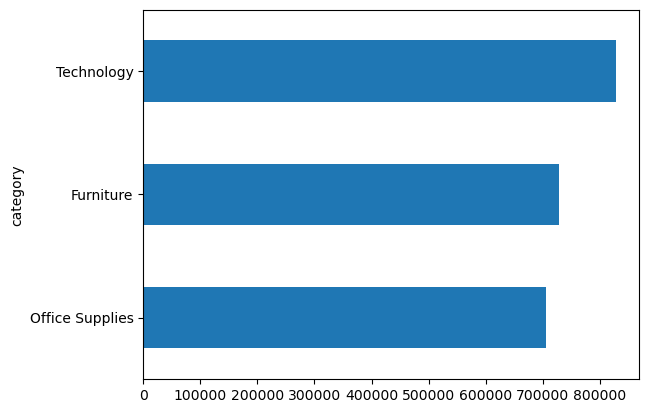

In [55]:
df.groupby('category')['sales'].sum().sort_values().plot(kind='barh')

In [56]:
df.columns = df.columns.str.strip().str.lower()

<Axes: ylabel='category'>

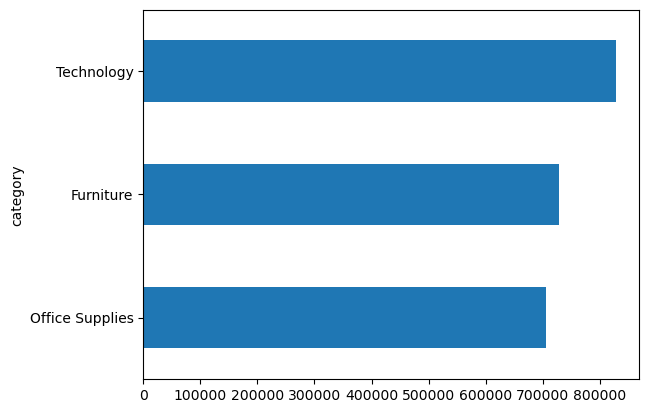

In [59]:
df.groupby('category')['sales'].sum().sort_values().plot(kind='barh')

### Insight

A análise de vendas por categoria mostra que a categoria com maior volume de vendas concentra a maior parte da receita da empresa.

Isso indica que estratégias comerciais e de marketing devem priorizar essa categoria para maximizar resultados.

<Axes: xlabel='order date'>

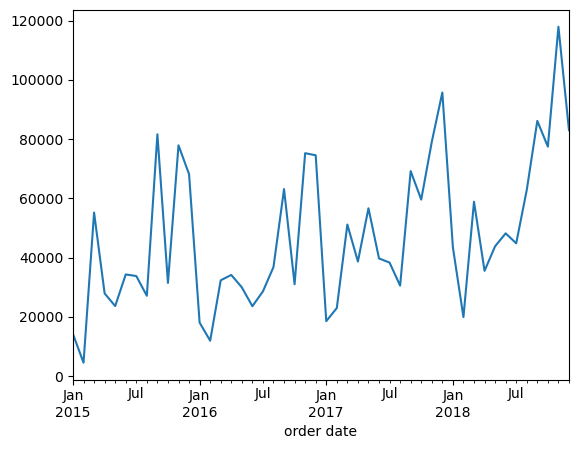

In [64]:
df['order date'] = pd.to_datetime(df['order date'], dayfirst=True, errors='coerce')

vendas_mes = df.groupby(df['order date'].dt.to_period('M'))['sales'].sum()

vendas_mes.plot()

### 📈 Insight Temporal

Observa-se uma tendência consistente de crescimento nas vendas ao longo do tempo, indicando expansão das operações ou aumento da demanda.

Entretanto, há recorrência de quedas no mês de janeiro em determinados anos, sugerindo um comportamento sazonal.

Esse padrão pode impactar o planejamento estratégico e reforça a necessidade de ações específicas para o início do ano, como campanhas promocionais ou ajustes de estoque.

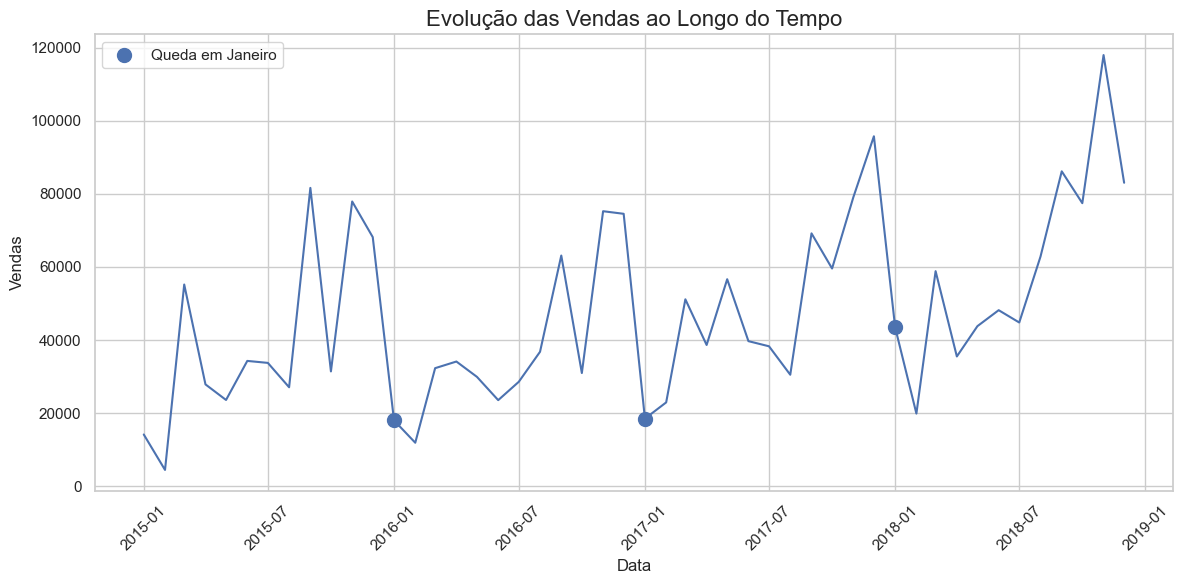

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

plt.figure(figsize=(12,6))

# linha SEM pontos
sns.lineplot(x=vendas_mes.index, y=vendas_mes.values)

# apenas janeiro com queda
jan_queda = vendas_mes[
    (vendas_mes.index.month == 1) &
    (vendas_mes < vendas_mes.shift(1))
]

plt.scatter(jan_queda.index, jan_queda.values, label='Queda em Janeiro', s=100)

plt.title('Evolução das Vendas ao Longo do Tempo', fontsize=16)
plt.xlabel('Data')
plt.ylabel('Vendas')

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

<Axes: title={'center': 'Crescimento Mensal (%)'}, xlabel='order date'>

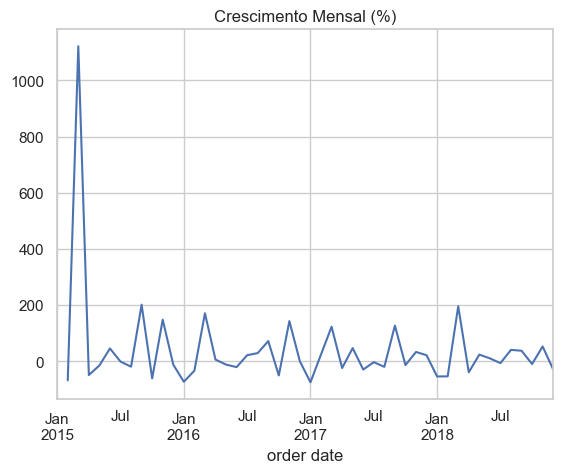

In [86]:
crescimento = vendas_mes.pct_change() * 100

crescimento.plot(title='Crescimento Mensal (%)')

### 📈 Crescimento

A análise de crescimento mensal evidencia variações significativas ao longo do tempo, com períodos de expansão e retração, indicando comportamento volátil nas vendas.

In [88]:
vendas_mes.sort_values(ascending=False).head(5)

order date
2018-11-01    117938.1550
2017-12-01     95739.1210
2018-09-01     86152.8880
2018-12-01     83030.3888
2015-09-01     81623.5268
Name: sales, dtype: float64

Os meses com maior volume de vendas concentram-se em períodos específicos, sugerindo sazonalidade ou campanhas bem-sucedidas.

In [89]:
vendas_mes.sort_values().head(5)

order date
2015-02-01     4519.8920
2016-02-01    11951.4110
2015-01-01    14205.7070
2016-01-01    18066.9576
2017-01-01    18542.4910
Name: sales, dtype: float64

Os meses com menor volume de vendas são janeiro e fevereiro, o que pode indicar uma sazonalidade. Já os meses com maior volume de vendas são novembro e dezembro, o que é comum devido às compras de fim de ano.

In [90]:
df.groupby(['region', df['order date'].dt.to_period('M')])['sales'].sum()

region   order date
Central  2015-01        1533.966
         2015-02        1233.174
         2015-03        5827.602
         2015-04        3712.340
         2015-05        4044.522
                         ...    
West     2018-08       25471.374
         2018-09       27107.217
         2018-10       21203.092
         2018-11       28718.207
         2018-12       29652.095
Name: sales, Length: 192, dtype: float64

<Axes: xlabel='order date'>

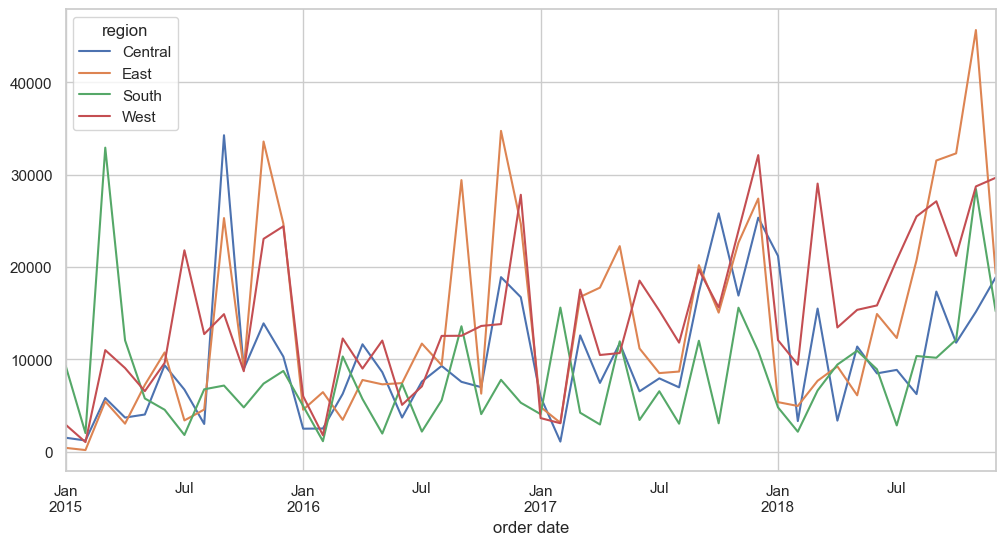

In [96]:
pivot = df.pivot_table(
    values='sales',
    index=df['order date'].dt.to_period('M'),
    columns='region',
    aggfunc='sum'
)

pivot.plot(figsize=(12,6))


In [98]:
top = df.groupby('product name')['sales'].sum().sort_values(ascending=False)

top.head(10).sum() / top.sum()

np.float64(0.10816547662247314)

Os 10 produtos com maior volume de vendas representam cerca de 10,8% da receita total, evidenciando baixa concentração.

Esse padrão indica um portfólio diversificado, reduzindo a dependência de itens específicos e tornando a operação mais resiliente a variações de demanda.